In [1]:
import streamlit as st
import math
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix, roc_curve, auc
# from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
%matplotlib inline
import joblib
from sklearn.utils import resample
from helpers import *

In [2]:
data = pd.read_csv("data/HAM10000_metadata.csv")
data.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10124 non-null  object 
 1   image_id      10124 non-null  object 
 2   dx            10124 non-null  object 
 3   dx_type       10124 non-null  object 
 4   age           10067 non-null  float64
 5   sex           10124 non-null  object 
 6   localization  10124 non-null  object 
 7   dataset       10124 non-null  object 
dtypes: float64(1), object(7)
memory usage: 632.9+ KB


In [4]:
data_no_null = data.copy()

In [5]:
data_no_null["age"].fillna(data_no_null["age"].mode(),inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_13488\1757973194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_no_null["age"].fillna(data_no_null["age"].mode(),inplace=True)


In [6]:
data_no_null.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10124 non-null  object 
 1   image_id      10124 non-null  object 
 2   dx            10124 non-null  object 
 3   dx_type       10124 non-null  object 
 4   age           10067 non-null  float64
 5   sex           10124 non-null  object 
 6   localization  10124 non-null  object 
 7   dataset       10124 non-null  object 
dtypes: float64(1), object(7)
memory usage: 632.9+ KB


In [7]:
# Mapping
malignant = ["mel", "bcc", "akiec", "vasc"] #1
benign = ["nv", "df", "bkl"]  #0
data_no_null = data_no_null.drop(columns=['lesion_id', 'image_id'])
data_no_null = data_no_null[data_no_null["dx"].isin(malignant + benign)].copy()
data_no_null["diagnosis_binary"] = data_no_null["dx"].apply(lambda x: 1 if x in malignant else 0)
data_no_null["sex"] = data_no_null["sex"].map({"male": 1, "female": 0})


In [8]:
data_no_null.head()

,dx,dx_type,age,sex,localization,dataset,diagnosis_binary
0,bkl,histo,80.0,1.0,scalp,vidir_modern,0
1,bkl,histo,80.0,1.0,scalp,vidir_modern,0
2,bkl,histo,80.0,1.0,scalp,vidir_modern,0
3,bkl,histo,80.0,1.0,scalp,vidir_modern,0
4,bkl,histo,75.0,1.0,ear,vidir_modern,0


In [9]:
cat_cols = ['dx', 'dx_type', 'localization', 'dataset']
le = LabelEncoder()
for col in cat_cols:
    data_no_null[col] = le.fit_transform(data_no_null[col])

In [10]:
data_no_null.head()

,dx,dx_type,age,sex,localization,dataset,diagnosis_binary
0,2,3,80.0,1.0,11,1,0
1,2,3,80.0,1.0,11,1,0
2,2,3,80.0,1.0,11,1,0
3,2,3,80.0,1.0,11,1,0
4,2,3,75.0,1.0,4,1,0


In [11]:
data_no_null["diagnosis_binary"].value_counts()

diagnosis_binary
0    7919
1    2096
Name: count, dtype: int64

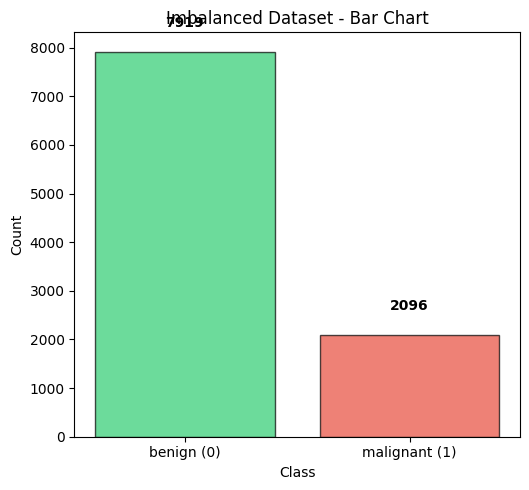

Imbalance Ratio: 3.78:1 (benign:malignant)


In [12]:
plt.figure(figsize=(10, 5))

# Bar plot
plt.subplot(1, 2, 1)
counts = data_no_null['diagnosis_binary'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['benign (0)', 'malignant (1)'], counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Imbalanced Dataset - Bar Chart')

for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imbalance Ratio: {counts[0]/counts[1]:.2f}:1 (benign:malignant)")

In [13]:
melanoma_data = data_no_null[data_no_null['diagnosis_binary'] == 0]
benign_data = data_no_null[data_no_null['diagnosis_binary'] == 1]
# Giảm melanoma = benign
df_melanoma_downsampled = melanoma_data.sample(n=len(benign_data),random_state=42)
# Data cân bằng
balanced_data = pd.concat([df_melanoma_downsampled, benign_data]).sample(frac=1,random_state=42)

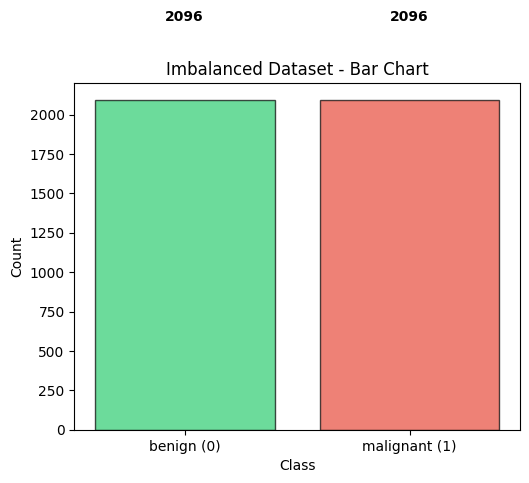

Imbalance Ratio: 1.00:1 (benign:malignant)


In [14]:
plt.figure(figsize=(10, 5))

# Bar plot
plt.subplot(1, 2, 1)
counts = balanced_data['diagnosis_binary'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['benign (0)', 'malignant (1)'], counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Imbalanced Dataset - Bar Chart')

for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imbalance Ratio: {counts[0]/counts[1]:.2f}:1 (benign:malignant)")

In [15]:
feature = ["age","sex", "localization"]
X = balanced_data[feature]
y= balanced_data["diagnosis_binary"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state=42)

In [17]:
# Imputer
impute = SimpleImputer(strategy="most_frequent")
X_train_impute = impute.fit_transform(X_train)
X_test_impute = impute.transform(X_test)

# Scaler
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train_impute)
X_test_scaler = scaler.transform(X_test_impute)
print("Kích thước tập huấn luyện:", X_train_scaler.shape)
print("Kích thước tập kiểm tra:", X_test_scaler.shape)

# Model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaler, y_train)


Kích thước tập huấn luyện: (3353, 3)
Kích thước tập kiểm tra: (839, 3)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [33]:
joblib.dump(impute, "model/imputer.pkl")

['model/imputer.pkl']

In [34]:
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [18]:
joblib.dump(svm_model, "model/svm_model_binary.pkl")
print("Model saved!")

Model saved!


In [19]:
y_pred = svm_model.predict(X_test_scaler)
print(f"Accuracy {accuracy_score(y_test,y_pred)}")
print(f"Precision {precision_score(y_test,y_pred)}")
print(f"Recall {recall_score(y_test,y_pred)}")
print(f"F1 Score {f1_score(y_test,y_pred)}")


Accuracy 0.7079856972586412
Precision 0.7289293849658315
Recall 0.7174887892376681
F1 Score 0.7231638418079096


In [23]:
metrics = {
    "Accuracy" : accuracy_score(y_test,y_pred),
    "Precision": precision_score(y_test,y_pred),
    "Recall" :  recall_score(y_test,y_pred),
    "F1 Score" :f1_score(y_test,y_pred)
}

In [24]:
joblib.dump(metrics, "model/metrics.pkl")

['model/metrics.pkl']

In [20]:
print(classification_report(y_test, y_pred, target_names=['Melanoma','Benign']))

              precision    recall  f1-score   support

    Melanoma       0.69      0.70      0.69       393
      Benign       0.73      0.72      0.72       446

    accuracy                           0.71       839
   macro avg       0.71      0.71      0.71       839
weighted avg       0.71      0.71      0.71       839



In [25]:
cm = confusion_matrix(y_test, y_pred)

In [26]:
cm

array([[274, 119],
       [126, 320]])

In [27]:
joblib.dump(cm, "model/confusion_matrix.pkl")

['model/confusion_matrix.pkl']

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

In [30]:
roc_data = {
    "fpr": fpr,
    "tpr": tpr,
    "roc_auc": roc_auc
}

joblib.dump(roc_data, "model/roc_data.pkl")

['model/roc_data.pkl']

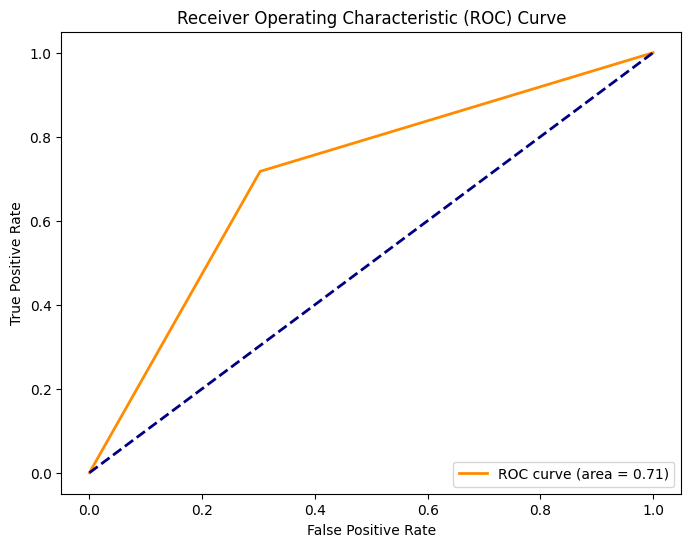

AUC: 0.7073


In [29]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc:.4f}")

In [ ]:
def plot_decision_boundary(X, y, model):
    # Tạo meshgrid để vẽ vùng
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Dự đoán trên meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Vẽ contour (vùng phân cách)
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Vẽ scatter plot các điểm data
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=50)

    # Label và title
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('SVM Decision Boundary for Skin Cancer(PCA-reduced to 2D)')
    plt.colorbar(label='Class (0: Benign, 1: Melanoma)')
    plt.show()

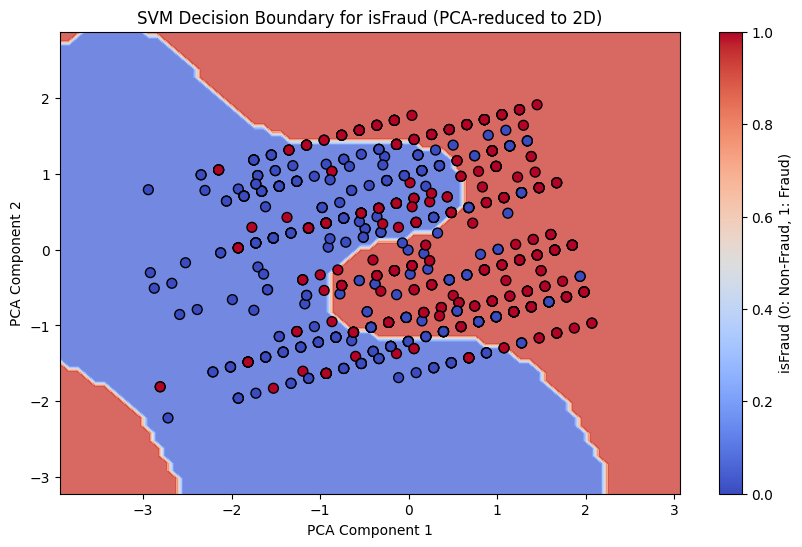

In [32]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

seed = 42

# Apply PCA to reduce the data to 2 components for visualization
pca = PCA(n_components=2, random_state=seed)
x_train_pca = pca.fit_transform(X_train_scaler)
x_test_pca = pca.transform(X_test_scaler)

# Train a new SVM model on the PCA-transformed data
svm_model_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model_pca.fit(x_train_pca, y_train)

# Now plot the decision boundary using the PCA-transformed data and the new model
plot_decision_boundary(x_test_pca, y_test, svm_model_pca)